# 1. lyap_k

Maximal Lyapunov exponent with `nolitisea.lyapunov.lyap_k.lyap_k`(Kantz algorithm).

For every radius `eps` of a geometric ladder and every embedding
dimension `m = min_dim .. dim` the Kantz statistic

    S(eps, m, dt) = < log ||v(t + dt)|| >

is accumulated: the neighbours of every reference point are the series
indices inside the `eps`-ball of its initial condition (first two
embedding coordinates); they are then followed for `max_steps` steps
regardless of their subsequent separation, the mean squared separation
over the neighbours is formed for every evolution time and its
logarithm is averaged over the reference points.  The slope of `S` in
its linear region estimates the maximal Lyapunov exponent.  Neighbours
within `theiler` indices of the reference point are excluded.

In [2]:
from nolitisea.generate.henon import henon
from nolitisea.lyapunov.lyap_k import lyap_k

# Henon map: the maximal Lyapunov exponent is about 0.4185 per iterate.
x, _ = henon(n=20000)

res = lyap_k(
    x,
    dim=5,        # maximal embedding dimension
    delay=1,      # time delay (discrete map: 1)
    max_steps=20, # evolution horizon
    n_ref=2000,   # number of reference points
    theiler=20,    # exclude temporally correlated neighbours
    n_jobs=-1
)
print(f"eps: {res['eps'].round(4)}")
print(f"dim: {res['dim']}, times: 0..{res['times'][-1]}, s2: {res['s2'].shape}")

eps: [0.0026 0.0045 0.0081 0.0144 0.0256]
dim: [2 3 4 5], times: 0..20, s2: (5, 4, 21)


## Kantz statistic

`S` grows linearly while the neighbour separations expand
exponentially; its slope in that region estimates the maximal Lyapunov
exponent.  The curves for the different radii overlap in the linear
region and bend down once the separations reach the attractor size.

eps = 0.002558: slope = 0.4349 (expected about 0.4185)
eps = 0.004548: slope = 0.4336 (expected about 0.4185)
eps = 0.008088: slope = 0.4313 (expected about 0.4185)
eps = 0.01438: slope = 0.4310 (expected about 0.4185)
eps = 0.02558: slope = 0.4251 (expected about 0.4185)


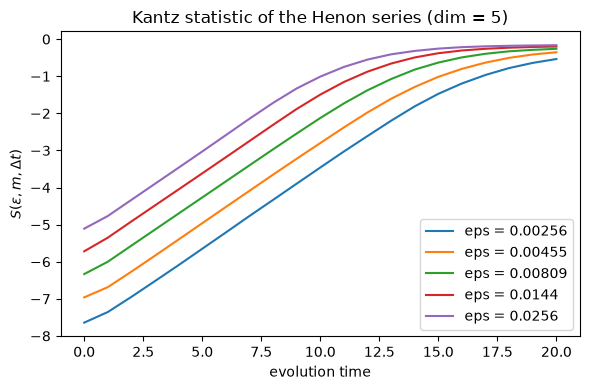

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4))
for eps, curve in zip(res["eps"], res["s2"][:, -1, :]):
    ax.plot(res["times"], curve, label=f"eps = {eps:.3g}")
    # Linear fit in the growth region (t = 1 .. 10).
    t = res["times"][1:11]
    slope = np.polyfit(t, curve[1:11], 1)[0]
    print(f"eps = {eps:.4g}: slope = {slope:.4f} (expected about 0.4185)")
ax.set_xlabel("evolution time")
ax.set_ylabel(r"$S(\varepsilon, m, \Delta t)$")
ax.set_title("Kantz statistic of the Henon series (dim = 5)")
ax.legend()
plt.tight_layout()
plt.show()

# 2. lyap_r

Maximal Lyapunov exponent with `nolitisea.lyapunov.lyap_r.lyap_r`(Rosenstein
algorithm).

For every reference point a processing radius `eps` is grown from
`eps0` by a factor of 1.1 until the `eps`-ball contains at least
one eligible neighbour.  The nearest strictly non-identical
candidate (ties broken by smallest index) is kept and evolved for
`max_steps` steps.  The Rosenstein statistic

    S(dt) = < log ||v(t + dt)|| >

averages the log pair separation over the reference points whose
separation has not collapsed to zero at the given evolution time.
Its slope in the linear region estimates the maximal Lyapunov
exponent.  Points within `min_sep` indices of the reference are
excluded.

In [5]:
from nolitisea.lyapunov.lyap_r import lyap_r

# Henon map: the maximal Lyapunov exponent is about 0.4185 per iterate.
x, _ = henon(n=20000)

res = lyap_r(
    x,
    dim=5,        # embedding dimension
    delay=1,      # time delay (discrete map: 1)
    max_steps=20, # evolution horizon
    theiler=20,   # exclude temporally correlated neighbours
)
print(f"times: {res['times']}")
print(f"divergence shape: {res['divergence'].shape}")

times: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
divergence shape: (21,)


## Rosenstein statistic

`S` grows linearly while the pair separations expand
exponentially (the stretching phase); its slope is the maximal
Lyapunov exponent.  The curve then bends down once the
separations reach the attractor size, and eventually the mean
separation has stabilised.

slope t in [1,11): 0.4142 (expected about 0.4185)


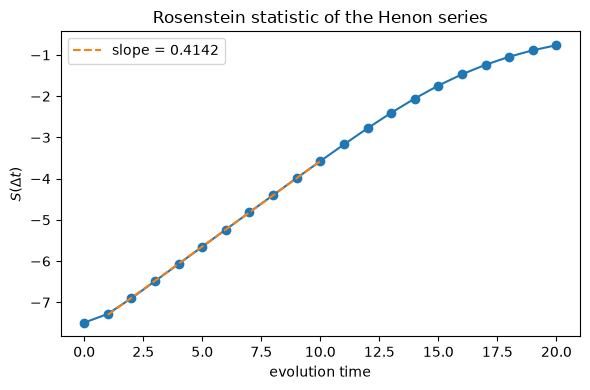

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(res["times"], res["divergence"], marker='o')

# Linear fit in the growth region (t = 1 .. 10).
t = res["times"][1:11]
slope = np.polyfit(t, res["divergence"][1:11], 1)[0]
ax.plot(t, slope * t + np.polyfit(t, res["divergence"][1:11], 1)[1],
        '--', label=f"slope = {slope:.4f}")
print(f"slope t in [1,11): {slope:.4f} (expected about 0.4185)")

ax.set_xlabel("evolution time")
ax.set_ylabel(r"$S(\Delta t)$")
ax.set_title("Rosenstein statistic of the Henon series")
ax.legend()
plt.tight_layout()
plt.show()

# 3. lyap_spec

Full Lyapunov spectrum with `nolitisea.lyapunov.lyap_spec.lyap_spec`
(Sano–Sawada algorithm).

For every reference point a local linear model of the flow is fitted
from the `n_neighbors` nearest neighbours of its delay-embedded state.
A random set of `alldim` perturbation vectors is evolved with this
model, and every `delay` steps the vectors are re-orthogonalised
(QR decomposition); the average log stretch factors

    lambda_j = < log |R_jj| > / delay

give the full spectrum of `alldim = n_vars * embed` exponents in
descending order.  The Kaplan–Yorke (information) dimension follows
from the spectrum as

    D_KY = k + sum(lambda_1..lambda_k) / |lambda_{k+1}|

with `k` the largest index whose cumulative sum is non-negative.

In [ ]:
from nolitisea.lyapunov.lyap_spec import lyap_spec

# Henon map: lambda_1 is about 0.4185 and the spectrum sums to
# ln(|det J|) = ln(0.3), so lambda_2 is about ln(0.3) - 0.4185 = -1.62.
x, _ = henon(n=20000)

res = lyap_spec(
    x,
    embed=2,        # embedding dimension (alldim = 2 exponents)
    n_iter=5000,    # number of reference points
    n_neighbors=30, # neighbours per local linear model
)
print(f"exponents: {res['exponents'].round(4)}")
print(f"sum: {res['exponents'].sum():.4f} (ln(0.3) = {np.log(0.3):.4f})")
print(f"Kaplan-Yorke dimension: {res['ky_dim']:.4f} (expected about 1.26)")

## Running averages of the spectrum

Each running average `running[:, j]` converges to the `j`-th exponent
as more reference points are processed; the final flat level of every
curve is the estimate.  The dashed lines mark the theoretical Henon
values `lambda_1 = 0.4185` and `lambda_2 = ln(0.3) - lambda_1`.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
for j, curve in enumerate(res["running"].T):
    ax.plot(res["times"], curve, label=rf"$\lambda_{j + 1}$")

lam1 = 0.4185
lam2 = np.log(0.3) - lam1
ax.axhline(lam1, ls="--", color="gray", lw=1)
ax.axhline(lam2, ls="--", color="gray", lw=1)

ax.set_xlabel("reference points")
ax.set_ylabel("running average")
ax.set_title("Running Lyapunov spectrum of the Henon series")
ax.legend()
plt.tight_layout()
plt.show()